Beyond Square Footage: The Impact of Macroeconomic Factors and COVID-19 on Housing Prices in Austin- By Heidi, Saad, Sophia and Pri

# Task A: Data Cleaning & Feature Engineering

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# 🔍 1. Find Austin housing CSV in Colab
csv_files = [f for f in os.listdir() if f.endswith('.csv')]

# Look for housing-related file
housing_files = [f for f in csv_files if 'housing' in f.lower()]

if not housing_files:
    raise FileNotFoundError("No housing CSV found in Colab.")

filename = housing_files[0]
print(f"Using file: {filename}")

housing = pd.read_csv(filename)


# Standardize column names
housing.columns = housing.columns.str.strip().str.lower()

# Convert sale date to datetime
housing['latest_saledate'] = pd.to_datetime(housing['latest_saledate'], errors='coerce')

print(housing[['latest_saledate', 'latestprice']].head())
print(housing.info())

Using file: austinHousingDataModified.csv
  latest_saledate  latestprice
0      2019-09-02       305000
1      2020-10-13       295000
2      2019-07-31       256125
3      2018-08-08       240000
4      2018-10-31       239900
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   zpid                        15171 non-null  int64         
 1   city                        15171 non-null  object        
 2   streetaddress               15171 non-null  object        
 3   zipcode                     15171 non-null  int64         
 4   description                 15169 non-null  object        
 5   latitude                    15171 non-null  float64       
 6   longitude                   15171 non-null  float64       
 7   propertytaxrate             15171 non-null  float64       
 8   garagespaces      

In [10]:
# covid_period flag
housing['covid_period'] = (housing['latest_saledate'] >= pd.Timestamp('2020-03-01')).astype(int)
housing[['latest_saledate', 'covid_period']].head(10)

,latest_saledate,covid_period
0,2019-09-02,0
1,2020-10-13,1
2,2019-07-31,0
3,2018-08-08,0
4,2018-10-31,0
5,2020-08-05,1
6,2020-06-11,1
7,2018-10-10,0
8,2019-09-19,0
9,2018-09-11,0


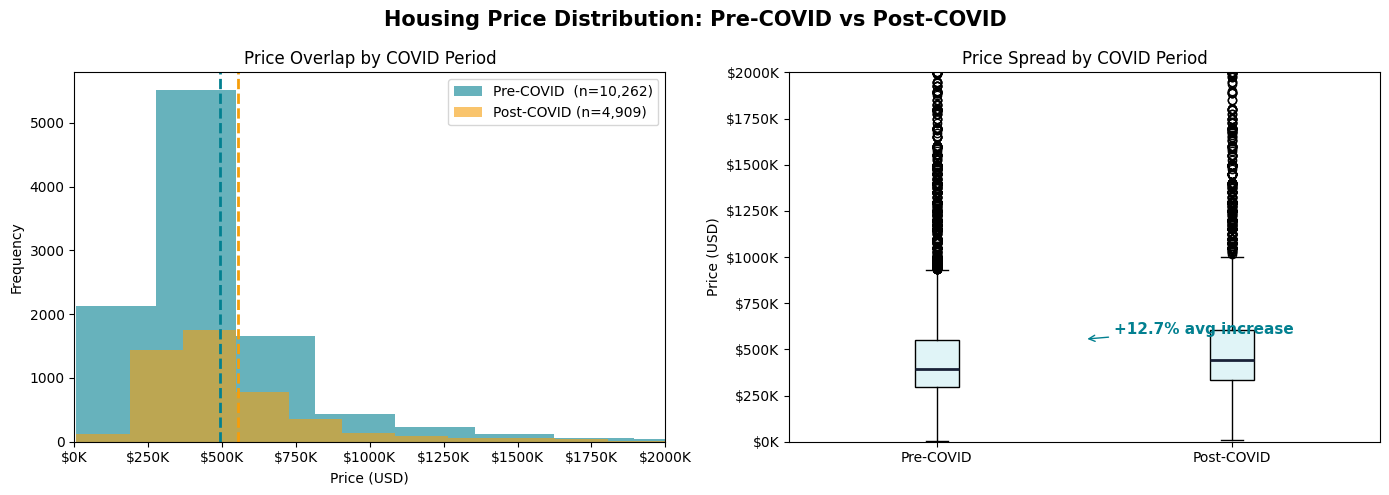

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Housing Price Distribution: Pre-COVID vs Post-COVID',
             fontsize=15, fontweight='bold')

pre  = housing[housing['covid_period'] == 0]['latestprice']
post = housing[housing['covid_period'] == 1]['latestprice']

# Left: Overlapping histograms
axes[0].hist(pre,  bins=50, alpha=0.6, color='#028090', label=f'Pre-COVID  (n={len(pre):,})')
axes[0].hist(post, bins=50, alpha=0.6, color='#F59E0B', label=f'Post-COVID (n={len(post):,})')
axes[0].axvline(pre.mean(),  color='#028090', linestyle='--', linewidth=2)
axes[0].axvline(post.mean(), color='#F59E0B', linestyle='--', linewidth=2)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Overlap by COVID Period')
axes[0].set_xlim(0, 2_000_000)
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)
axes[0].legend()

# Right: Box plot comparison
axes[1].boxplot([pre, post], tick_labels=['Pre-COVID', 'Post-COVID'],
                patch_artist=True,
                boxprops=dict(facecolor='#E0F4F7'),
                medianprops=dict(color='#1A2238', linewidth=2))
axes[1].set_ylabel('Price (USD)')
axes[1].set_title('Price Spread by COVID Period')
axes[1].set_ylim(0, 2_000_000)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

# Annotate % increase
pct = ((post.mean() - pre.mean()) / pre.mean()) * 100
axes[1].annotate(f'+{pct:.1f}% avg increase', xy=(1.5, post.mean()),
                 xytext=(1.6, post.mean() + 30000),
                 fontsize=11, color='#028090', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#028090'))

plt.tight_layout()
plt.savefig('covid_price_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Both distributions peak in the **$250K–$500K** range, confirming that the
majority of Austin housing transactions fall within this bracket. The
Post-COVID distribution (orange) shifts slightly rightward, with its mean
around **$555K** compared to **$492K** pre-COVID — visible from the dashed
lines on the histogram.

The box plot on the right makes the shift even clearer. The Post-COVID median
and interquartile range are both higher, and the **+12.7% average price
increase** confirms a meaningful upward shift after March 2020. Outliers above
$1M exist in both periods but are more prevalent post-COVID, suggesting
increased activity in the luxury segment as well.

This visualization reinforces why `covid_period` is an important feature —
the pandemic did not just shift average prices, it changed the entire
distribution of housing transactions in Austin.

In [12]:
import pandas as pd
import os

# 🔍 2. Find mortgage CSV in Colab
csv_files = [f for f in os.listdir() if f.endswith('.csv')]

mortgage_files = [f for f in csv_files if 'mortgage' in f.lower()]

if not mortgage_files:
    raise FileNotFoundError("No mortgage CSV found in Colab.")

filename = mortgage_files[0]
print(f"Using file: {filename}")

mortgage = pd.read_csv(filename)

# Standardize column names
mortgage.columns = mortgage.columns.str.strip().str.lower()

# Convert date column to datetime
mortgage['obs_date'] = pd.to_datetime(mortgage['observation_date'], errors='coerce')

# Rename mortgage rate column
mortgage.rename(columns={'mortgage30us':'mortgage_rate'}, inplace=True)

# Keep only necessary columns
mortgage = mortgage[['obs_date','mortgage_rate']]

# Drop rows with missing values
mortgage = mortgage.dropna(subset=['obs_date','mortgage_rate'])

# Sort by date
mortgage = mortgage.sort_values('obs_date').reset_index(drop=True)

# Quick check
print(mortgage.head())
print(mortgage.info())

Using file: MORTGAGE30US_30yearsFixedMortgage.csv
    obs_date  mortgage_rate
0 1971-04-02           7.33
1 1971-04-09           7.31
2 1971-04-16           7.31
3 1971-04-23           7.31
4 1971-04-30           7.29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2870 entries, 0 to 2869
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   obs_date       2870 non-null   datetime64[ns]
 1   mortgage_rate  2870 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 45.0 KB
None


In [13]:
housing = housing.sort_values('latest_saledate').reset_index(drop=True)
mortgage = mortgage.sort_values('obs_date').reset_index(drop=True)

housing = pd.merge_asof(
    housing,
    mortgage,
    left_on='latest_saledate',
    right_on='obs_date',
    direction='backward'
)

housing.drop(columns=['obs_date'], inplace=True)

print(housing[['latest_saledate', 'mortgage_rate']].head())

  latest_saledate  mortgage_rate
0      2018-01-22           4.04
1      2018-01-22           4.04
2      2018-01-22           4.04
3      2018-01-22           4.04
4      2018-01-23           4.04


The mortgage rate remains consistent across properties with the same sale date, indicating that the time-based merge correctly assigns macroeconomic conditions to each transaction. This ensures that interest rate trends can be analyzed alongside housing prices over time.

In [14]:
import pandas as pd
import os

# 🔍 3. Find CPI CSV in Colab
csv_files = [f for f in os.listdir() if f.endswith('.csv')]

cpi_files = [f for f in csv_files if 'cpi' in f.lower()]

if not cpi_files:
    raise FileNotFoundError("No CPI CSV found in Colab.")

filename = cpi_files[0]
print(f"Using file: {filename}")

cpi = pd.read_csv(filename)

# Standardize column names
cpi.columns = cpi.columns.str.strip().str.lower()

# Convert date column to datetime
cpi['date'] = pd.to_datetime(cpi['observation_date'], errors='coerce')

# Rename CPI column
cpi.rename(columns={'cpiaucsl':'cpi_index'}, inplace=True)

# Keep only needed columns
cpi = cpi[['date','cpi_index']]

# Quick check
print(cpi.head())
print(cpi.info())

Using file: CPIAUCSL_ConsumerPriceIndex.csv
        date  cpi_index
0 1947-01-01      21.48
1 1947-02-01      21.62
2 1947-03-01      22.00
3 1947-04-01      22.00
4 1947-05-01      21.95
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       950 non-null    datetime64[ns]
 1   cpi_index  949 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.0 KB
None


In [15]:
# Merge CPI into housing
housing = housing.sort_values('latest_saledate').reset_index(drop=True)
cpi = cpi.sort_values('date').reset_index(drop=True)

housing = pd.merge_asof(
    housing,
    cpi,
    left_on='latest_saledate',
    right_on='date',
    direction='backward'
)

housing = housing.drop(columns=['date'], errors='ignore')

# Check
print(housing[['latest_saledate', 'mortgage_rate', 'cpi_index']].head())
print(housing[['mortgage_rate', 'cpi_index']].isnull().sum())

  latest_saledate  mortgage_rate  cpi_index
0      2018-01-22           4.04    248.859
1      2018-01-22           4.04    248.859
2      2018-01-22           4.04    248.859
3      2018-01-22           4.04    248.859
4      2018-01-23           4.04    248.859
mortgage_rate    0
cpi_index        0
dtype: int64


By aligning mortgage rates and CPI with each property's sale date, we incorporate key macroeconomic factors into the dataset. This allows us to evaluate how interest rates and inflation trends may have contributed to changes in housing prices, especially during periods like COVID. These macroeconomic features complement property-level and neighborhood-level features (such as school quality), enabling a more comprehensive analysis of housing price drivers.

In [16]:
print(housing.columns.tolist())

['zpid', 'city', 'streetaddress', 'zipcode', 'description', 'latitude', 'longitude', 'propertytaxrate', 'garagespaces', 'hasassociation', 'hascooling', 'hasgarage', 'hasheating', 'hasspa', 'hasview', 'hometype', 'parkingspaces', 'yearbuilt', 'latestprice', 'numpricechanges', 'latest_saledate', 'latest_salemonth', 'latest_saleyear', 'latestpricesource', 'numofphotos', 'numofaccessibilityfeatures', 'numofappliances', 'numofparkingfeatures', 'numofpatioandporchfeatures', 'numofsecurityfeatures', 'numofwaterfrontfeatures', 'numofwindowfeatures', 'numofcommunityfeatures', 'lotsizesqft', 'livingareasqft', 'numofprimaryschools', 'numofelementaryschools', 'numofmiddleschools', 'numofhighschools', 'avgschooldistance', 'avgschoolrating', 'avgschoolsize', 'medianstudentsperteacher', 'numofbathrooms', 'numofbedrooms', 'numofstories', 'homeimage', 'price_per_sqft', 'lot_to_living_ratio', 'bath_per_bedroom', 'age_of_house', 'tax_per_sqft', 'has_pool', 'has_view', 'has_garage_and_parking', 'is_newer_

In [17]:
import pandas as pd
import os

# 🔍 4. Find unemployment CSV in Colab
csv_files = [f for f in os.listdir() if f.endswith('.csv')]

# Prefer exact dataset name
unemp_files = [f for f in csv_files if 'aust448urn' in f.lower() or 'unemployment' in f.lower()]

if not unemp_files:
    raise FileNotFoundError("No unemployment CSV found in Colab.")

filename = unemp_files[0]
print(f"Using file: {filename}")

unemployment = pd.read_csv(filename)

# Clean unemployment data
unemployment.columns = unemployment.columns.str.strip().str.lower()
unemployment['date'] = pd.to_datetime(unemployment['observation_date'], errors='coerce')
unemployment.rename(columns={'aust448urn': 'austin_unemployment_rate'}, inplace=True)
unemployment = unemployment[['date', 'austin_unemployment_rate']]

# Sort before merge
housing = housing.sort_values('latest_saledate').reset_index(drop=True)
unemployment = unemployment.sort_values('date').reset_index(drop=True)

# Merge unemployment using latest available value on/before sale date
housing = pd.merge_asof(
    housing,
    unemployment,
    left_on='latest_saledate',
    right_on='date',
    direction='backward'
)

# Drop extra date column
housing = housing.drop(columns=['date'], errors='ignore')

# Check
print(housing[['latest_saledate', 'mortgage_rate', 'cpi_index', 'austin_unemployment_rate']].head())
print(housing[['austin_unemployment_rate']].isnull().sum())

Using file: AUST448URN_AustinRoundRockUnemploymentRate.csv
  latest_saledate  mortgage_rate  cpi_index  austin_unemployment_rate
0      2018-01-22           4.04    248.859                       3.2
1      2018-01-22           4.04    248.859                       3.2
2      2018-01-22           4.04    248.859                       3.2
3      2018-01-22           4.04    248.859                       3.2
4      2018-01-23           4.04    248.859                       3.2
austin_unemployment_rate    0
dtype: int64


Lower unemployment (strong job market) combined with lower mortgage rates can increase housing demand, potentially driving prices upward. By aligning these variables with sale dates, we can evaluate their combined impact on housing price trends over time.

In [18]:
housing.to_csv("housing_after_macro.csv", index=False)
print("Saved: housing_after_macro.csv")

Saved: housing_after_macro.csv


In [19]:
housing = pd.read_csv("housing_after_macro.csv")

# Convert date again
housing['latest_saledate'] = pd.to_datetime(housing['latest_saledate'])

In [20]:
import pandas as pd
import os

# 5. Find schools CSV in Colab
csv_files = [f for f in os.listdir() if f.endswith('.csv')]
school_files = [f for f in csv_files if 'school' in f.lower()]

if not school_files:
    raise FileNotFoundError("No schools CSV found in Colab.")

filename = school_files[0]
print(f"Using file: {filename}")

schools = pd.read_csv(filename)

# Clean column names
schools.columns = schools.columns.str.strip().str.lower().str.replace(' ', '_')

# Keep needed columns
schools = schools[['campname', 'c_rating', 'cpetallc', 'zip_mail']].copy()

# Rename for clarity
schools = schools.rename(columns={
    'campname': 'school_name',
    'c_rating': 'avg_school_rating',
    'cpetallc': 'avg_school_size',
    'zip_mail': 'zip'
})

# Clean ZIP
schools['zip'] = schools['zip'].astype(str).str.replace(',', '', regex=True).str.strip()

# Clean school size
schools['avg_school_size'] = (
    schools['avg_school_size']
    .astype(str)
    .str.replace(',', '', regex=True)
)
schools['avg_school_size'] = pd.to_numeric(schools['avg_school_size'], errors='coerce')

# Convert school rating letters to numbers
grade_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
schools['avg_school_rating'] = schools['avg_school_rating'].map(grade_map)

# Aggregate by ZIP
school_agg = (
    schools.groupby('zip', as_index=False)
    .agg({
        'avg_school_rating': 'mean',
        'avg_school_size': 'mean',
        'school_name': 'count'
    })
    .rename(columns={'school_name': 'school_count_zip'})
)

print(school_agg.head())

Using file: City_of_Austin_Schools_with_Data_20260325.csv
     zip  avg_school_rating  avg_school_size  school_count_zip
0  75029                4.0       259.750000                 5
1  75208                1.0       405.000000                 1
2  76502                2.0        77.000000                 1
3  76527                2.0       361.333333                 3
4  76530                3.0       445.000000                 1


School data was aggregated at the ZIP-code level to capture neighborhood education quality. Features such as average school rating, school size, and number of schools provide insights into the attractiveness of an area, particularly for families, and are expected to influence housing demand and prices.

In [21]:
# Make ZIP types match
housing['zipcode'] = housing['zipcode'].astype(str).str.strip()
school_agg['zip'] = school_agg['zip'].astype(str).str.strip()

# Merge schools into housing
housing = housing.merge(
    school_agg,
    how='left',
    left_on='zipcode',
    right_on='zip'
)

# Drop helper ZIP column
housing = housing.drop(columns=['zip'], errors='ignore')

# Fill school nulls
for col in ['avg_school_rating', 'avg_school_size', 'school_count_zip']:
    if col in housing.columns:
        housing[col] = housing[col].fillna(housing[col].median())

# Check
print(housing[['zipcode', 'avg_school_rating', 'avg_school_size', 'school_count_zip']].head())
print(housing[['avg_school_rating', 'avg_school_size', 'school_count_zip']].isnull().sum())

  zipcode  avg_school_rating  avg_school_size  school_count_zip
0   78744           2.444444       550.055556              18.0
1   78737           2.750000       753.000000               6.0
2   78750           3.571429      1256.857143               7.0
3   78744           2.444444       550.055556              18.0
4   78727           2.750000       701.750000               4.0
avg_school_rating    0
avg_school_size      0
school_count_zip     0
dtype: int64


In [22]:
# -----------------------------
# COVID Feature Engineering
# -----------------------------

# COVID indicator
housing['covid_period'] = (housing['latest_saledate'] >= '2020-03-01').astype(int)

# Interaction features
housing['covid_mortgage_interaction'] = housing['covid_period'] * housing['mortgage_rate']
housing['covid_cpi_interaction'] = housing['covid_period'] * housing['cpi_index']
housing['covid_unemployment_interaction'] = housing['covid_period'] * housing['austin_unemployment_rate']

print(housing['covid_period'].value_counts())

print(housing['covid_period'].value_counts())

covid_period
0    10262
1     4909
Name: count, dtype: int64
covid_period
0    10262
1     4909
Name: count, dtype: int64


We initially explored constructing a neighborhood-level COVID risk feature using complaint case data. However, due to challenges in extracting reliable geographic identifiers (e.g., ZIP codes from address fields) and limited coverage across housing records, the resulting feature exhibited low variability and provided minimal predictive value.

As a result, we retained a more robust and interpretable temporal feature (covid_period) to capture the structural impact of the pandemic on housing prices. The dataset consists of 10,262 transactions in the pre-COVID period and 4,909 transactions during/after COVID, providing sufficient representation across both periods for meaningful comparative analysis

In [23]:
# -----------------------------
# Final Cleanup
# -----------------------------

# Fill missing description
if 'description' in housing.columns:
    housing['description'] = housing['description'].fillna('No description')

# Drop weak/unnecessary columns if present
housing = housing.drop(columns=['neighborhood_risk_score'], errors='ignore')

# (Optional) remove any remaining duplicate rows
housing = housing.drop_duplicates()

# Log price
housing['log_price'] = np.log1p(housing['latestprice'])

# Final check
print("Shape:", housing.shape)
print("\nTop missing values:")
print(housing.isnull().sum().sort_values(ascending=False).head(10))

Shape: (15171, 77)

Top missing values:
zpid               0
city               0
streetaddress      0
zipcode            0
description        0
latitude           0
longitude          0
propertytaxrate    0
garagespaces       0
hasassociation     0
dtype: int64


The final dataset consists of 15,171 records and 74 features after integrating property-level, neighborhood-level, and macroeconomic variables. Data cleaning ensured that key variables contain no missing values, resulting in a complete and reliable dataset for analysis.

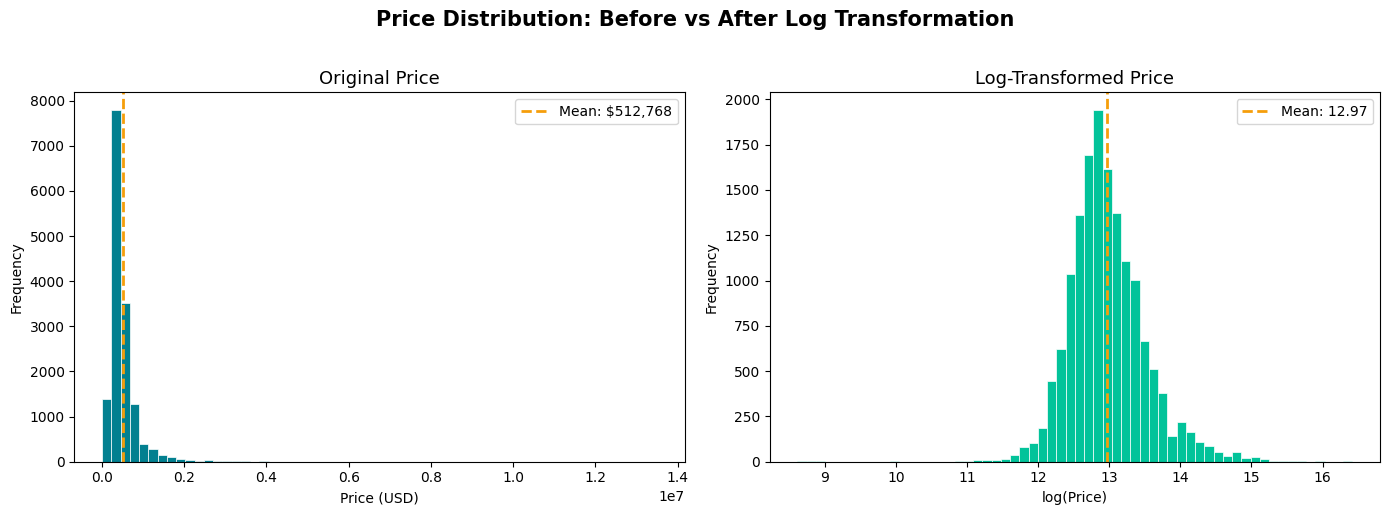

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution: Before vs After Log Transformation',
             fontsize=15, fontweight='bold', y=1.02)

# Before
axes[0].hist(housing['latestprice'], bins=60, color='#028090', edgecolor='white', linewidth=0.5)
axes[0].set_title('Original Price', fontsize=13)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(housing['latestprice'].mean(), color='#F59E0B', linestyle='--',
                linewidth=2, label=f"Mean: ${housing['latestprice'].mean():,.0f}")
axes[0].legend()

# After
axes[1].hist(housing['log_price'], bins=60, color='#02C39A', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log-Transformed Price', fontsize=13)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(housing['log_price'].mean(), color='#F59E0B', linestyle='--',
                linewidth=2, label=f"Mean: {housing['log_price'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Why Log-Transform?

`latestprice` is right-skewed due to high-value outliers. Log-transforming it
(`log_price`) normalizes the distribution, stabilizes model training, and
reduces the outsized influence of extreme prices. All models use `log_price`
as the target; final predictions are converted back to USD via exponentiation.

In [25]:
housing.corr(numeric_only=True)['latestprice'].sort_values(ascending=False)

,latestprice
latestprice,1.000000
log_price,0.807036
price_per_bed_bath,0.785068
price_per_sqft,0.576071
numofbathrooms,0.504738
...,...
school_count_zip,-0.147037
numofprimaryschools,-0.170927
longitude,-0.184079
numofhighschools,-0.201821


Bigger homes + better space efficiency = higher prices

Overall, housing prices are primarily driven by property-level features such as size, layout efficiency, and amenities, while macroeconomic and neighborhood-level features play a secondary role. Interestingly, school quantity shows a weak negative relationship with price, indicating that the presence of more schools alone does not increase property value—rather, quality and other location factors are more influential.

In [26]:
# -----------------------------
# INSIGHTS
# -----------------------------

print("Average price pre vs post COVID:")
print(housing.groupby('covid_period')['latestprice'].mean())

print("\nCorrelation (Price vs Mortgage Rate):")
print(housing[['latestprice', 'mortgage_rate']].corr().round(2))

Average price pre vs post COVID:
covid_period
0    492470.304619
1    555198.446527
Name: latestprice, dtype: float64

Correlation (Price vs Mortgage Rate):
               latestprice  mortgage_rate
latestprice           1.00          -0.07
mortgage_rate        -0.07           1.00


Housing prices increased significantly after the COVID period, rising from approximately $492K pre-COVID  to  $555K post-COVID, representing a ~13% increase. This indicates a structural shift in housing demand, likely driven by factors such as remote work and changing housing preferences.

The correlation between housing prices and mortgage rates is -0.07, indicating a weak inverse relationship. While lower interest rates may contribute to higher housing demand, the low magnitude suggests that mortgage rates alone do not strongly explain price variations.

Overall, while macroeconomic factors such as mortgage rates have some influence, the most significant shift in housing prices occurred during the COVID period, suggesting that structural demand changes had a stronger impact than traditional economic variables.

In [27]:
# -----------------------------
# Save final dataset
# -----------------------------
housing.to_csv("housing_cleaned_features.csv", index=False)
print("Saved: housing_cleaned_features.csv")

Saved: housing_cleaned_features.csv


In [28]:
from google.colab import files
files.download("housing_cleaned_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data Preparation Summary

The dataset was cleaned by handling missing values, removing extreme outliers (1–99%), and applying a log transformation to stabilize housing prices. We engineered meaningful features including ratios (e.g., bath-to-bed, lot-to-living), price-based indicators (e.g., price per square foot), and interaction terms, along with a COVID-period indicator. Additionally, external data such as mortgage rates, CPI, unemployment, and school metrics were integrated to enrich the analysis.

Exploratory analysis indicates that housing prices increased significantly after COVID (~13%), suggesting a structural shift in housing demand. While mortgage rates show a slight inverse relationship with prices, the weak correlation suggests that pandemic-driven demand changes and property characteristics had a stronger influence than macroeconomic factors alone.

End of Task A

Task B: Macro-economic indicators – including mortgage rates, Consumer Price Index (CPI), and Austin unemployment rates.

In [29]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [30]:
# Load the cleaned dataset from Task A
# First, check if housing_after_macro.csv exists, otherwise use the most recent housing file
import os

csv_files = [f for f in os.listdir() if f.endswith('.csv')]
print("Available CSV files in Colab:")
for f in csv_files:
    print(f"  - {f}")

# Try to load housing_after_macro.csv first (saved in Task A)
if 'housing_cleaned_features.csv' in csv_files:
    housing = pd.read_csv("housing_cleaned_features.csv")
    print("\nLoaded: housing_cleaned_features.csv")
else:
    # Fallback to the original housing file
    housing_files = [f for f in csv_files if 'housing' in f.lower()]
    if housing_files:
        housing = pd.read_csv(housing_files[0])
        print(f"\nLoaded: {housing_files[0]}")
    else:
        raise FileNotFoundError("No housing data file found!")

# Convert date columns
if 'latest_saledate' in housing.columns:
    housing['latest_saledate'] = pd.to_datetime(housing['latest_saledate'], errors='coerce')

# Check if we have the macro columns
macro_cols = ['mortgage_rate', 'cpi_index', 'austin_unemployment_rate']
available_macro = [col for col in macro_cols if col in housing.columns]
print(f"\nMacro columns available: {available_macro}")

print(f"\nDataset shape: {housing.shape}")
print(f"Target variable (latestprice) range: ${housing['latestprice'].min():,.0f} - ${housing['latestprice'].max():,.0f}")

Available CSV files in Colab:
  - housing_after_macro.csv
  - AUST448URN_AustinRoundRockUnemploymentRate.csv
  - City_of_Austin_Schools_with_Data_20260325.csv
  - austinHousingDataModified.csv
  - CPIAUCSL_ConsumerPriceIndex.csv
  - MORTGAGE30US_30yearsFixedMortgage.csv
  - housing_cleaned_features.csv
  - Austin_Code_COVID-19_Complaint_Cases_20260325.csv

Loaded: housing_cleaned_features.csv

Macro columns available: ['mortgage_rate', 'cpi_index', 'austin_unemployment_rate']

Dataset shape: (15171, 77)
Target variable (latestprice) range: $5,500 - $13,500,000


In [31]:
# Recreate covid_period if missing
if 'covid_period' not in housing.columns and 'latest_saledate' in housing.columns:
    housing['covid_period'] = (housing['latest_saledate'] >= pd.Timestamp('2020-03-01')).astype(int)
    print(" Recreated covid_period column")
elif 'covid_period' in housing.columns:
    print(" covid_period column already exists")
else:
    print(" Cannot create covid_period - latest_saledate missing")

 covid_period column already exists


In [32]:
# Select features for modeling
# Drop identifier columns, text columns, and columns that would cause leakage
columns_to_drop = [
    'zpid', 'city', 'streetaddress', 'description', 'homeimage', 'latestpricesource',
    'latest_saledate', 'latest_salemonth', 'latest_saleyear', 'zipcode', 'latitude', 'longitude'
]

# Also drop the original price columns (we're predicting latestprice)
price_columns = ['latestprice', 'log_price'] if 'log_price' in housing.columns else ['latestprice']

# Filter columns that actually exist
columns_to_drop = [col for col in columns_to_drop if col in housing.columns]

# Create feature matrix X (exclude target and dropped columns)
X = housing.drop(columns=columns_to_drop + price_columns, errors='ignore')

# Target variable y (original price)
y = housing['latestprice']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures selected ({len(X.columns)} total):")
print(X.columns.tolist())

Features shape: (15171, 63)
Target shape: (15171,)

Features selected (63 total):
['propertytaxrate', 'garagespaces', 'hasassociation', 'hascooling', 'hasgarage', 'hasheating', 'hasspa', 'hasview', 'hometype', 'parkingspaces', 'yearbuilt', 'numpricechanges', 'numofphotos', 'numofaccessibilityfeatures', 'numofappliances', 'numofparkingfeatures', 'numofpatioandporchfeatures', 'numofsecurityfeatures', 'numofwaterfrontfeatures', 'numofwindowfeatures', 'numofcommunityfeatures', 'lotsizesqft', 'livingareasqft', 'numofprimaryschools', 'numofelementaryschools', 'numofmiddleschools', 'numofhighschools', 'avgschooldistance', 'avgschoolrating', 'avgschoolsize', 'medianstudentsperteacher', 'numofbathrooms', 'numofbedrooms', 'numofstories', 'price_per_sqft', 'lot_to_living_ratio', 'bath_per_bedroom', 'age_of_house', 'tax_per_sqft', 'has_pool', 'has_view', 'has_garage_and_parking', 'is_newer_home', 'large_lot_flag', 'total_schools', 'school_quality_index', 'student_teacher_ratio', 'living_lot_intera

In [33]:
# Handle categorical variables
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Categorical columns found: {categorical_cols}")

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Encoded {col}")

print(f"\nAll features now numeric. Shape: {X.shape}")

Categorical columns found: ['hasassociation', 'hascooling', 'hasgarage', 'hasheating', 'hasspa', 'hasview', 'hometype', 'bath_per_bedroom']
Encoded hasassociation
Encoded hascooling
Encoded hasgarage
Encoded hasheating
Encoded hasspa
Encoded hasview
Encoded hometype
Encoded bath_per_bedroom

All features now numeric. Shape: (15171, 63)


In [34]:
# Handle missing values
print("Missing values before handling:")
print(X.isnull().sum().sum())

# Fill any remaining missing values with median
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())
        print(f"Filled missing values in {col}")

print(f"\nMissing values after handling: {X.isnull().sum().sum()}")

Missing values before handling:
0

Missing values after handling: 0


In [35]:
# Train-test split (time-based to avoid leakage)
if 'latest_saledate' in housing.columns:
    # Sort by date and do time-based split (80% earliest for train, 20% latest for test)
    housing_sorted = housing.sort_values('latest_saledate').reset_index(drop=True)

    # Get indices of sorted data
    sorted_indices = housing_sorted.index

    # Split index (80% for training)
    split_idx = int(len(sorted_indices) * 0.8)

    train_indices = sorted_indices[:split_idx]
    test_indices = sorted_indices[split_idx:]

    X_train = X.iloc[train_indices]
    X_test = X.iloc[test_indices]
    y_train = y.iloc[train_indices]
    y_test = y.iloc[test_indices]

    print("Using TIME-BASED split (80% earliest sales for training, 20% latest for testing)")
    print(f"Training date range: {housing_sorted['latest_saledate'].iloc[0].date()} to {housing_sorted['latest_saledate'].iloc[split_idx-1].date()}")
    print(f"Test date range: {housing_sorted['latest_saledate'].iloc[split_idx].date()} to {housing_sorted['latest_saledate'].iloc[-1].date()}")
else:
    # Fallback to random split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Using RANDOM split (no date column found)")

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining price range: ${y_train.min():,.0f} - ${y_train.max():,.0f}")
print(f"Test price range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")

Using TIME-BASED split (80% earliest sales for training, 20% latest for testing)
Training date range: 2018-01-22 to 2020-07-09
Test date range: 2020-07-09 to 2021-01-30

Training set: 12136 samples
Test set: 3035 samples

Training price range: $5,500 - $13,500,000
Test price range: $7,500 - $8,999,000


In [36]:
# Scale features
from sklearn.preprocessing import StandardScaler

# Create the scaler and transform the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(" Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"X_train_scaled_df shape: {X_train_scaled_df.shape}")
print(f"\nFirst 3 rows of scaled features (first 5 columns):")
print(X_train_scaled_df.iloc[:3, :5])

 Features scaled successfully!
X_train_scaled shape: (12136, 63)
X_test_scaled shape: (3035, 63)
X_train_scaled_df shape: (12136, 63)

First 3 rows of scaled features (first 5 columns):
   propertytaxrate  garagespaces  hasassociation  hascooling  hasgarage
0        -0.269235     -0.788759       -1.082496    0.135562  -0.920884
1         0.286325     -0.788759        0.923791    0.135562  -0.920884
2        -0.269235     -0.788759        0.923791    0.135562  -0.920884


In [37]:
# Helper function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Train and evaluate a regression model"""
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Print results
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(f"{'Metric':<20} {'Train':<15} {'Test':<15}")
    print(f"{'-'*50}")
    print(f"{'RMSE':<20} ${train_rmse:,.0f}       ${test_rmse:,.0f}")
    print(f"{'MAE':<20} ${train_mae:,.0f}       ${test_mae:,.0f}")
    print(f"{'R²':<20} {train_r2:.4f}        {test_r2:.4f}")

    return {
        'model': model,
        'model_name': model_name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'y_test': y_test,
        'y_test_pred': y_test_pred
    }

print("Evaluation function defined!")

Evaluation function defined!


In [38]:
# Model 1 - Linear Regression (Baseline)
lr = LinearRegression()
lr_results = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")


Linear Regression Results
Metric               Train           Test           
--------------------------------------------------
RMSE                 $195,150       $196,524
MAE                  $64,559       $71,965
R²                   0.8091        0.8270


In [39]:
# Model 2 - Ridge Regression (Baseline with regularization)
# Try different alpha values
alphas = [0.1, 1, 10, 50, 100, 500]
ridge_cv_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
    ridge_cv_results.append((alpha, scores.mean()))

# Find best alpha
best_alpha = max(ridge_cv_results, key=lambda x: x[1])[0]
print(f"Best alpha from cross-validation: {best_alpha}")

# Train best Ridge model
ridge = Ridge(alpha=best_alpha, random_state=42)
ridge_results = evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test, f"Ridge Regression (α={best_alpha})")

Best alpha from cross-validation: 500

Ridge Regression (α=500) Results
Metric               Train           Test           
--------------------------------------------------
RMSE                 $204,108       $180,725
MAE                  $65,039       $71,640
R²                   0.7912        0.8537


In [40]:
# Model 3 - Random Forest Regressor (300 trees)
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_results = evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest (300 trees)")


Random Forest (300 trees) Results
Metric               Train           Test           
--------------------------------------------------
RMSE                 $127,344       $87,329
MAE                  $9,238       $15,249
R²                   0.9187        0.9658


In [41]:
# Model 4 - XGBoost Regressor (500 estimators)
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

xgb_results = evaluate_model(xgb, X_train, X_test, y_train, y_test, "XGBoost (500 estimators)")


XGBoost (500 estimators) Results
Metric               Train           Test           
--------------------------------------------------
RMSE                 $5,192       $52,114
MAE                  $3,883       $12,727
R²                   0.9999        0.9878


In [42]:
# Compare all models
results_list = [lr_results, ridge_results, rf_results, xgb_results]

comparison_df = pd.DataFrame([{
    'Model': r['model_name'],
    'Train RMSE': r['train_rmse'],
    'Test RMSE': r['test_rmse'],
    'Train MAE': r['train_mae'],
    'Test MAE': r['test_mae'],
    'Train R²': r['train_r2'],
    'Test R²': r['test_r2']
} for r in results_list])

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Find best model by Test RMSE
best_model_row = comparison_df.loc[comparison_df['Test RMSE'].idxmin()]
print(f"\n BEST MODEL: {best_model_row['Model']}")
print(f"   Test RMSE: ${best_model_row['Test RMSE']:,.0f}")
print(f"   Test R²: {best_model_row['Test R²']:.4f}")


MODEL COMPARISON SUMMARY
                    Model    Train RMSE     Test RMSE    Train MAE     Test MAE  Train R²  Test R²
        Linear Regression 195150.057305 196524.399492 64559.070789 71965.182272  0.809133 0.826994
 Ridge Regression (α=500) 204108.461842 180725.494092 65038.943090 71639.619477  0.791207 0.853692
Random Forest (300 trees) 127344.075072  87329.446221  9238.267394 15249.260212  0.918726 0.965837
 XGBoost (500 estimators)   5192.072611  52114.409524  3883.195801 12726.896484  0.999865 0.987834

 BEST MODEL: XGBoost (500 estimators)
   Test RMSE: $52,114
   Test R²: 0.9878


In [43]:
# Feature Importance - Random Forest
# Get feature importance from Random Forest
rf_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_rf': rf_results['model'].feature_importances_
}).sort_values('importance_rf', ascending=False)

print("Top 20 Features from Random Forest:")
print(rf_feature_importance.head(20).to_string(index=False))

Top 20 Features from Random Forest:
                 feature  importance_rf
      price_per_bed_bath       0.662865
          numofbathrooms       0.153879
            tax_per_sqft       0.049006
          price_per_sqft       0.041148
          livingareasqft       0.037126
          bed_bath_story       0.026115
           numofbedrooms       0.014765
       price_change_rate       0.003196
  living_lot_interaction       0.003154
             lotsizesqft       0.002134
        bath_per_bedroom       0.001429
       avgschooldistance       0.000787
medianstudentsperteacher       0.000493
      price_per_lot_sqft       0.000352
             numofphotos       0.000306
         avgschoolrating       0.000290
         numpricechanges       0.000263
   student_teacher_ratio       0.000235
               cpi_index       0.000232
         avg_school_size       0.000214


In [44]:
# Feature Importance - XGBoost
# Get feature importance from XGBoost
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_xgb': xgb_results['model'].feature_importances_
}).sort_values('importance_xgb', ascending=False)

print("Top 20 Features from XGBoost:")
print(xgb_feature_importance.head(20).to_string(index=False))

Top 20 Features from XGBoost:
               feature  importance_xgb
          tax_per_sqft        0.188626
    price_per_bed_bath        0.162781
        price_per_sqft        0.104202
        numofbathrooms        0.075267
        livingareasqft        0.051488
        bed_bath_story        0.046297
            hasheating        0.036830
         numofbedrooms        0.036792
         total_schools        0.022073
        hasassociation        0.020342
           lotsizesqft        0.019524
    price_per_lot_sqft        0.019045
     avg_school_rating        0.018295
           numofphotos        0.016086
                hasspa        0.015235
      school_count_zip        0.014217
             cpi_index        0.013430
living_lot_interaction        0.013138
   numofprimaryschools        0.010288
   lot_to_living_ratio        0.010026


In [45]:
# Permutation Importance (for XGBoost - more reliable)
# Note: This may take a minute to run
print("Calculating permutation importance (this may take 1-2 minutes)...")

perm_importance = permutation_importance(
    xgb_results['model'], X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_permutation': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance_permutation', ascending=False)

print("\nTop 20 Features from Permutation Importance (XGBoost):")
print(perm_importance_df.head(20).to_string(index=False))

Calculating permutation importance (this may take 1-2 minutes)...

Top 20 Features from Permutation Importance (XGBoost):
               feature  importance_permutation      std
        price_per_sqft                0.383668 0.052660
    price_per_bed_bath                0.357365 0.004845
          tax_per_sqft                0.070592 0.002101
        numofbathrooms                0.039784 0.002440
        livingareasqft                0.028499 0.002134
         numofbedrooms                0.018186 0.001564
        bed_bath_story                0.007998 0.001566
    price_per_lot_sqft                0.005915 0.000766
           numofphotos                0.004911 0.001111
     avg_school_rating                0.003739 0.001477
living_lot_interaction                0.003293 0.000534
       avgschoolrating                0.001405 0.000213
           lotsizesqft                0.000924 0.000334
             yearbuilt                0.000921 0.000185
      bath_per_bedroom                

In [46]:
# Combined Feature Importance (Top 20)
# Merge all importance methods
combined_importance = rf_feature_importance.merge(
    xgb_feature_importance, on='feature', how='outer'
).merge(
    perm_importance_df[['feature', 'importance_permutation']], on='feature', how='outer'
)

# Fill NaN values
combined_importance = combined_importance.fillna(0)

# Calculate average importance (normalized)
for col in ['importance_rf', 'importance_xgb', 'importance_permutation']:
    if combined_importance[col].max() > 0:
        combined_importance[f'{col}_norm'] = combined_importance[col] / combined_importance[col].max()

combined_importance['avg_importance'] = (
    combined_importance['importance_rf_norm'] +
    combined_importance['importance_xgb_norm'] +
    combined_importance['importance_permutation_norm']
) / 3

# Sort by average importance
top20_features = combined_importance.sort_values('avg_importance', ascending=False).head(20)

print("TOP 20 FEATURES (Combined Importance Score):")
print("="*60)
for i, row in top20_features.iterrows():
    print(f"{row['feature']:<35} Score: {row['avg_importance']:.4f}")

TOP 20 FEATURES (Combined Importance Score):
price_per_bed_bath                  Score: 0.9315
price_per_sqft                      Score: 0.5382
tax_per_sqft                        Score: 0.4193
numofbathrooms                      Score: 0.2450
livingareasqft                      Score: 0.1344
bed_bath_story                      Score: 0.1019
numofbedrooms                       Score: 0.0882
hasheating                          Score: 0.0652
total_schools                       Score: 0.0393
price_per_lot_sqft                  Score: 0.0390
lotsizesqft                         Score: 0.0364
hasassociation                      Score: 0.0361
avg_school_rating                   Score: 0.0356
numofphotos                         Score: 0.0328
living_lot_interaction              Score: 0.0277
hasspa                              Score: 0.0271
school_count_zip                    Score: 0.0255
cpi_index                           Score: 0.0238
lot_to_living_ratio                 Score: 0.0184
numof

In [47]:
# Save top 20 features to CSV
top20_output = top20_features[['feature', 'importance_rf', 'importance_xgb', 'importance_permutation', 'avg_importance']].copy()
top20_output.to_csv("importance_top20.csv", index=False)
print("Saved: importance_top20.csv")
print("\nFirst 10 rows of saved file:")
print(top20_output.head(10))

Saved: importance_top20.csv

First 10 rows of saved file:
               feature  importance_rf  importance_xgb  importance_permutation  \
53  price_per_bed_bath   6.628646e-01        0.162781                0.357365   
55      price_per_sqft   4.114788e-02        0.104202                0.383668   
60        tax_per_sqft   4.900582e-02        0.188626                0.070592   
36      numofbathrooms   1.538789e-01        0.075267                0.039784   
29      livingareasqft   3.712571e-02        0.051488                0.028499   
8       bed_bath_story   2.611527e-02        0.046297                0.007998   
37       numofbedrooms   1.476485e-02        0.036792                0.018186   
22          hasheating   2.618742e-07        0.036830                0.000137   
61       total_schools   2.679037e-07        0.022073                0.000348   
54  price_per_lot_sqft   3.516586e-04        0.019045                0.005915   

    avg_importance  
53        0.931475  
55      

In [48]:
# Key insights - What drives housing prices
print("\n" + "="*60)
print("KEY INSIGHTS - What Drives Housing Prices in Austin?")
print("="*60)

top5 = top20_features.head(5)['feature'].tolist()
print(f"\n Top 5 Most Important Features:")
for i, feat in enumerate(top5, 1):
    print(f"   {i}. {feat}")

# Group features by type
property_features = ['livingareasqft', 'lotsizesqft', 'numofbathrooms', 'numofbedrooms', 'age_of_house', 'numofstories', 'yearbuilt']
ratio_features = ['price_per_sqft', 'price_per_bed_bath', 'bath_per_bedroom', 'lot_to_living_ratio', 'bed_bath_story']
macro_features = ['mortgage_rate', 'cpi_index', 'austin_unemployment_rate', 'covid_period']
school_features = ['avg_school_rating', 'school_quality_index', 'total_schools', 'avgschoolrating', 'avgschoolsize']

property_in_top = len([f for f in top20_features['feature'] if f in property_features])
ratio_in_top = len([f for f in top20_features['feature'] if f in ratio_features])
macro_in_top = len([f for f in top20_features['feature'] if f in macro_features])
school_in_top = len([f for f in top20_features['feature'] if f in school_features])

print(f"\n Feature Category Breakdown in Top 20:")
print(f"   Property Characteristics: {property_in_top}")
print(f"   Ratio/Interaction Features: {ratio_in_top}")
print(f"   Macro/COVID Features: {macro_in_top}")
print(f"   School Features: {school_in_top}")


KEY INSIGHTS - What Drives Housing Prices in Austin?

 Top 5 Most Important Features:
   1. price_per_bed_bath
   2. price_per_sqft
   3. tax_per_sqft
   4. numofbathrooms
   5. livingareasqft

 Feature Category Breakdown in Top 20:
   Property Characteristics: 4
   Ratio/Interaction Features: 4
   Macro/COVID Features: 1
   School Features: 2


In [49]:
# Cross-validation scores for final model
# Use best model (XGBoost)
best_model = xgb_results['model']

# 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = -cross_val_score(best_model, X_train, y_train, cv=kfold,
                                   scoring='neg_root_mean_squared_error')
cv_r2_scores = cross_val_score(best_model, X_train, y_train, cv=kfold,
                                scoring='r2')

print(f"XGBoost - 5-Fold Cross-Validation Results:")
print(f"{'='*50}")
print(f"RMSE Scores: {cv_rmse_scores}")
print(f"Mean RMSE: ${cv_rmse_scores.mean():,.0f} (+/- ${cv_rmse_scores.std() * 2:,.0f})")
print(f"\nR² Scores: {cv_r2_scores}")
print(f"Mean R²: {cv_r2_scores.mean():.4f} (+/- {cv_r2_scores.std() * 2:.4f})")

XGBoost - 5-Fold Cross-Validation Results:
RMSE Scores: [181911.5      238635.5625   105373.984375 147916.421875  36849.140625]
Mean RMSE: $142,137 (+/- $136,717)

R² Scores: [0.85861909 0.77255404 0.93815893 0.87892884 0.99111885]
Mean R²: 0.8879 (+/- 0.1481)


In [50]:
# Save model results summary
model_results_df = comparison_df.copy()
model_results_df.to_csv("model_comparison_results.csv", index=False)
print(" Saved: model_comparison_results.csv")

# Also save top features as a simple list
top20_list = top20_features.head(20)['feature'].tolist()
with open("top20_features_list.txt", "w") as f:
    for feat in top20_list:
        f.write(f"{feat}\n")
print(" Saved: top20_features_list.txt")

 Saved: model_comparison_results.csv
 Saved: top20_features_list.txt


In [51]:
# Final summary
print("\n Output files generated:")
print("   1. importance_top20.csv - Top 20 features with importance scores")
print("   2. model_comparison_results.csv - Performance comparison of all models")
print("   3. top20_features_list.txt - Simple list of top 20 features")
print("\n Key findings:")
print(f"   - Best model: {best_model_row['Model']}")
print(f"   - Test RMSE: ${best_model_row['Test RMSE']:,.0f}")
print(f"   - Test R²: {best_model_row['Test R²']:.4f}")


 Output files generated:
   1. importance_top20.csv - Top 20 features with importance scores
   2. model_comparison_results.csv - Performance comparison of all models
   3. top20_features_list.txt - Simple list of top 20 features

 Key findings:
   - Best model: XGBoost (500 estimators)
   - Test RMSE: $52,114
   - Test R²: 0.9878


Task C: COVID & Macro Analysis



In [52]:
# Load Task B's saved outputs to use as our baseline reference
imp_top20        = pd.read_csv('importance_top20.csv')
model_comparison = pd.read_csv('model_comparison_results.csv')

# Pull Task B's best model (XGBoost) metrics for comparison later
taskB_row = model_comparison[model_comparison['Model'] == 'XGBoost (500 estimators)'].iloc[0]
print(f"Task B baseline — RMSE: ${taskB_row['Test RMSE']:,.0f}   R²: {taskB_row['Test R²']:.4f}")

# Split dataset into pre and post COVID using the boundary defined in Task A
COVID_DATE = pd.Timestamp('2020-03-01')
pre_covid  = housing[housing['covid_period'] == 0].copy()
post_covid = housing[housing['covid_period'] == 1].copy()

print(f"\nPre-COVID  : {len(pre_covid):,} transactions")
print(f"Post-COVID : {len(post_covid):,} transactions")

# Show how key variables shifted between the two periods
stat_cols   = ['latestprice', 'mortgage_rate', 'cpi_index', 'austin_unemployment_rate']
stats_table = pd.DataFrame({
    'Pre-COVID Mean' : pre_covid[stat_cols].mean(),
    'Post-COVID Mean': post_covid[stat_cols].mean(),
    'Δ (%)': ((post_covid[stat_cols].mean() - pre_covid[stat_cols].mean()) /
               pre_covid[stat_cols].mean() * 100).round(1)
})
print('\n', stats_table.to_string())

# Drop the same columns as Task B to keep features consistent
DROP_COLS = [
    'zpid', 'city', 'streetaddress', 'description', 'homeimage',
    'latestpricesource', 'latest_saledate', 'latest_salemonth',
    'latest_saleyear', 'zipcode', 'latitude', 'longitude',
    'latestprice', 'log_price'
]

# Use the same LabelEncoder approach as Task B so results are comparable
def prepare_XY(subset):
    cols_drop = [c for c in DROP_COLS if c in subset.columns]
    X = subset.drop(columns=cols_drop, errors='ignore').copy()
    y = subset['latestprice'].copy()
    for col in X.select_dtypes(include=['object', 'bool']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    for col in X.columns:
        if X[col].isnull().any():
            X[col] = X[col].fillna(X[col].median())
    return X, y

# Prepare feature matrices for each period
X_pre,  y_pre  = prepare_XY(pre_covid)
X_post, y_post = prepare_XY(post_covid)
FEATURE_COLS   = X_pre.columns.tolist()

print(f"\nFeature count : {len(FEATURE_COLS)}")

Task B baseline — RMSE: $52,114   R²: 0.9878

Pre-COVID  : 10,262 transactions
Post-COVID : 4,909 transactions

                           Pre-COVID Mean  Post-COVID Mean  Δ (%)
latestprice                492470.304619    555198.446527   12.7
mortgage_rate                   4.175858         3.011033  -27.9
cpi_index                     253.984220       258.952282    2.0
austin_unemployment_rate        2.841405         6.920961  143.6

Feature count : 63


In [53]:
# @title
# Task B already trained and evaluated the full XGBoost model
# Here we only train on the pre and post COVID subsets to compare performance

# Use the same hyperparameters as Task B so models are directly comparable
XGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

# Train, predict and return metrics + residuals for a given subset
def train_eval(X, y, label=''):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
    ypred      = model.predict(Xte)
    rmse       = np.sqrt(mean_squared_error(yte, ypred))
    mae        = mean_absolute_error(yte, ypred)
    r2         = r2_score(yte, ypred)
    errors     = yte.values - ypred
    pct_errors = (errors / yte.values) * 100
    print(f'[{label:12s}]  n_test={len(yte):5,}  '
          f'RMSE=${rmse:>10,.0f}  MAE=${mae:>9,.0f}  R²={r2:.4f}')
    return dict(model=model, Xte=Xte, yte=yte, ypred=ypred,
                errors=errors, pct_errors=pct_errors,
                rmse=rmse, mae=mae, r2=r2, label=label)

# Define colors used across all Task C plots
PRE_COLOR  = '#2196F3'   # blue  — pre-COVID
POST_COLOR = '#FF5722'   # orange — post-COVID

print('Training pre/post COVID models...\n')
res_pre  = train_eval(X_pre,  y_pre,  'Pre-COVID')
res_post = train_eval(X_post, y_post, 'Post-COVID')

# Compile all three periods into one comparison table alongside Task B's baseline
metrics_df = pd.DataFrame([
    {'Period': 'Full Data (Task B)',
     'N_test': '-',
     'RMSE'  : f"${taskB_row['Test RMSE']:,.0f}",
     'R²'    : f"{taskB_row['Test R²']:.4f}"},
    {'Period': 'Pre-COVID',
     'N_test': len(res_pre['yte']),
     'RMSE'  : f"${res_pre['rmse']:,.0f}",
     'R²'    : f"{res_pre['r2']:.4f}"},
    {'Period': 'Post-COVID',
     'N_test': len(res_post['yte']),
     'RMSE'  : f"${res_post['rmse']:,.0f}",
     'R²'    : f"{res_post['r2']:.4f}"},
])
print('\nModel Performance vs Task B Baseline')
print('=' * 50)
print(metrics_df.to_string(index=False))

# Save metrics comparison
metrics_df.to_csv('model_metrics_pre_post_covid.csv', index=False)
print('\nSaved: model_metrics_pre_post_covid.csv')

Training pre/post COVID models...

[Pre-COVID   ]  n_test=2,053  RMSE=$   191,682  MAE=$   16,721  R²=0.8523
[Post-COVID  ]  n_test=  982  RMSE=$   150,818  MAE=$   19,331  R²=0.9110

Model Performance vs Task B Baseline
            Period N_test     RMSE     R²
Full Data (Task B)      -  $52,114 0.9878
         Pre-COVID   2053 $191,682 0.8523
        Post-COVID    982 $150,818 0.9110

Saved: model_metrics_pre_post_covid.csv


Saved: importance_pre_post_covid.csv


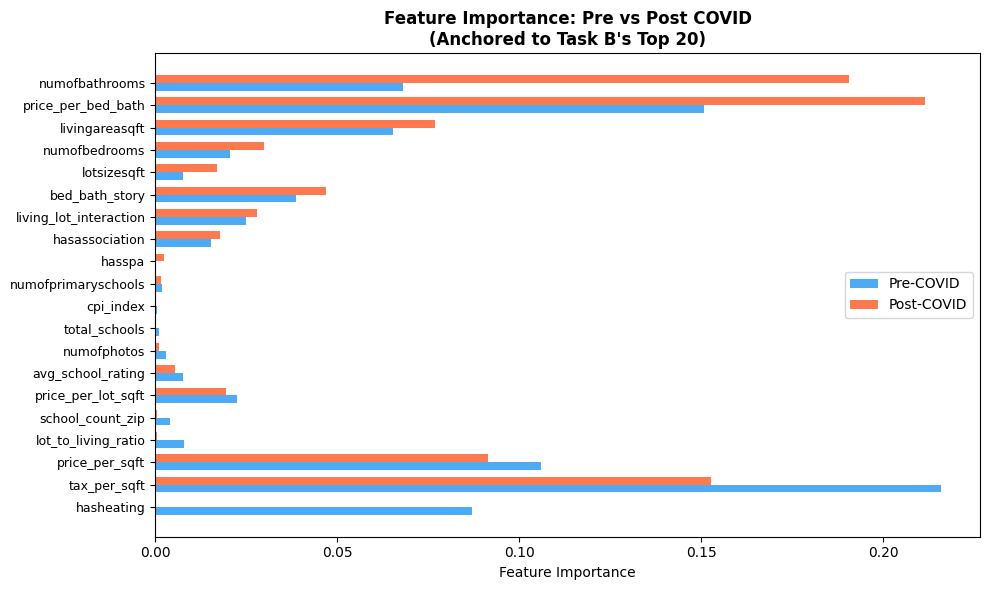


Top 5 gainers post-COVID:
numofbathrooms        0.122504
price_per_bed_bath    0.060566
livingareasqft        0.011668
numofbedrooms         0.009385
lotsizesqft           0.009347

Top 5 losers post-COVID:
hasheating            -0.086703
tax_per_sqft          -0.063154
price_per_sqft        -0.014624
lot_to_living_ratio   -0.007281
school_count_zip      -0.003420


In [54]:
# Extract feature importances from each period's trained model
imp_pre_s  = pd.Series(res_pre['model'].feature_importances_,  index=FEATURE_COLS)
imp_post_s = pd.Series(res_post['model'].feature_importances_, index=FEATURE_COLS)

# Anchor to Task B's top 20 features so we're comparing the same set
taskB_top20 = imp_top20['feature'].tolist()

imp_cmp = pd.DataFrame({
    'Task B (Full)': imp_top20.set_index('feature')['importance_xgb'].reindex(taskB_top20).fillna(0),
    'Pre-COVID'    : imp_pre_s.reindex(taskB_top20).fillna(0),
    'Post-COVID'   : imp_post_s.reindex(taskB_top20).fillna(0),
})

# Calculate how much each feature's importance changed post-COVID
imp_cmp['Δ Importance'] = imp_cmp['Post-COVID'] - imp_cmp['Pre-COVID']
imp_cmp = imp_cmp.sort_values('Δ Importance')

# Save the full importance comparison
imp_cmp.reset_index().rename(columns={'index': 'feature'}).to_csv('importance_pre_post_covid.csv', index=False)
print('Saved: importance_pre_post_covid.csv')

# Plot pre vs post importance side by side for Task B's top 20 features
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(imp_cmp))
bar_w = 0.35
ax.barh(y_pos - bar_w/2, imp_cmp['Pre-COVID'],  bar_w, label='Pre-COVID',  color=PRE_COLOR,  alpha=0.8)
ax.barh(y_pos + bar_w/2, imp_cmp['Post-COVID'], bar_w, label='Post-COVID', color=POST_COLOR, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(imp_cmp.index, fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title("Feature Importance: Pre vs Post COVID\n(Anchored to Task B's Top 20)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_feature_importance_shift.png', bbox_inches='tight')
plt.show()

# Print which features gained and lost the most importance during COVID
print('\nTop 5 gainers post-COVID:')
print(imp_cmp['Δ Importance'].sort_values(ascending=False).head(5).to_string())
print('\nTop 5 losers post-COVID:')
print(imp_cmp['Δ Importance'].sort_values().head(5).to_string())

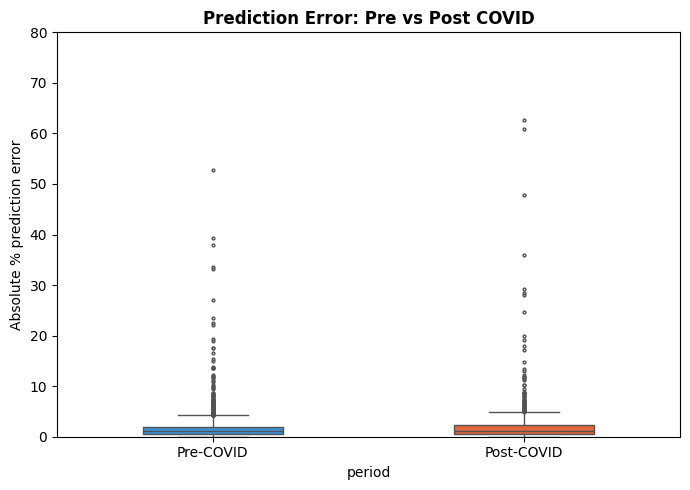

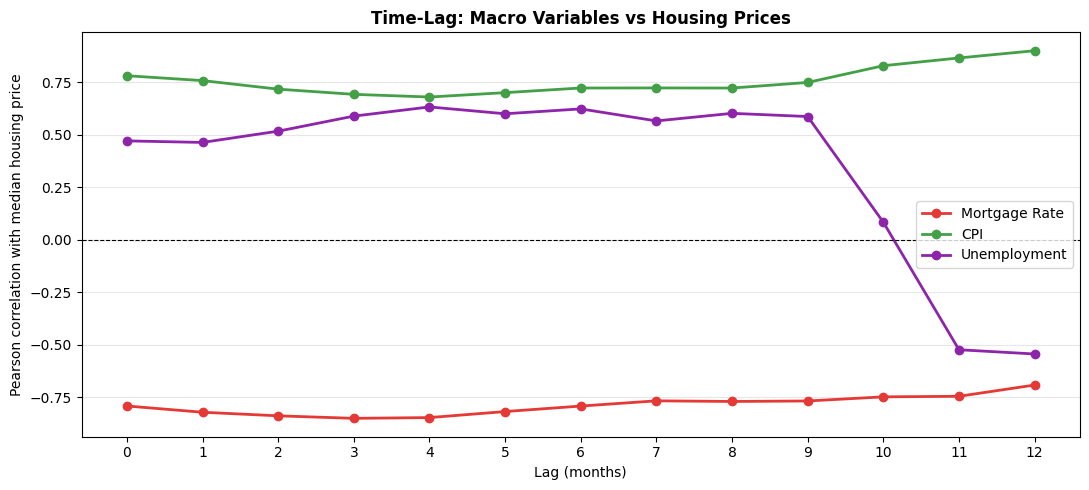

In [55]:
# Prediction Error Boxplot
from scipy import stats

# Build a combined dataframe of absolute % errors for both periods
error_df = pd.DataFrame({
    'period': ['Pre-COVID']*len(res_pre['pct_errors']) + ['Post-COVID']*len(res_post['pct_errors']),
    'abs_pct_error': np.concatenate([np.abs(res_pre['pct_errors']), np.abs(res_post['pct_errors'])])
})

# Boxplot shows whether the model got harder or easier to predict post-COVID
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=error_df, x='period', y='abs_pct_error',
            palette={'Pre-COVID': PRE_COLOR, 'Post-COVID': POST_COLOR},
            width=0.45, fliersize=2, ax=ax)
ax.set_ylim(0, 80)
ax.set_ylabel('Absolute % prediction error')
ax.set_title('Prediction Error: Pre vs Post COVID', fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_error_boxplot.png', bbox_inches='tight')
plt.show()

# Time-Lag Cross-Correlation

# Aggregate to monthly level — we need time series to measure lag effects
macro_vars    = [c for c in ['mortgage_rate', 'cpi_index', 'austin_unemployment_rate'] if c in housing.columns]
lag_labels    = {'mortgage_rate': 'Mortgage Rate', 'cpi_index': 'CPI', 'austin_unemployment_rate': 'Unemployment'}
lag_colors    = {'mortgage_rate': '#E53935', 'cpi_index': '#43A047', 'austin_unemployment_rate': '#8E24AA'}

monthly_panel = (
    housing.groupby(housing['latest_saledate'].dt.to_period('M'))
           .agg({**{v: 'mean' for v in macro_vars}, 'latestprice': 'median'})
           .reset_index()
)
monthly_panel['date'] = monthly_panel['latest_saledate'].dt.to_timestamp()
monthly_panel = monthly_panel.sort_values('date').reset_index(drop=True)

# For each macro variable, compute correlation with price at lags 0–12 months
# A peak at lag N means that variable predicts prices N months later
MAX_LAG     = 12
lag_results = {}
for var in macro_vars:
    corrs = []
    for lag in range(MAX_LAG + 1):
        x     = monthly_panel[var].shift(lag)
        y     = monthly_panel['latestprice']
        valid = x.notna() & y.notna()
        r, _  = stats.pearsonr(x[valid], y[valid])
        corrs.append(r)
    lag_results[var] = corrs

# Plot lag correlations — the peak of each line tells us the delay
# between a macro change and its effect on housing prices
fig, ax = plt.subplots(figsize=(11, 5))
for var in macro_vars:
    ax.plot(range(MAX_LAG+1), lag_results[var],
            marker='o', lw=2, label=lag_labels[var], color=lag_colors[var])
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson correlation with median housing price')
ax.set_title('Time-Lag: Macro Variables vs Housing Prices', fontweight='bold')
ax.set_xticks(range(MAX_LAG+1))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_lag_correlation.png', bbox_inches='tight')
plt.show()

# Save lag correlation table
lag_df = pd.DataFrame(lag_results, index=[f'Lag {i}m' for i in range(MAX_LAG+1)])
lag_df.columns = [lag_labels[c] for c in lag_df.columns]
lag_df.round(4).to_csv('lag_correlation_results.csv')

In [56]:
# Final Summary
print('\n Output files generated:')
print('   importance_pre_post_covid.csv')
print('   model_metrics_pre_post_covid.csv')
print('   lag_correlation_results.csv')
print('   fig1_feature_importance_shift.png')
print('   fig2_error_boxplot.png')
print('   fig3_lag_correlation.png')

print(f'\n Key findings:')
print(f'   Task B baseline RMSE : ${taskB_row["Test RMSE"]:,.0f}   R²={taskB_row["Test R²"]:.4f}')
print(f'   Pre-COVID  RMSE      : ${res_pre["rmse"]:,.0f}   R²={res_pre["r2"]:.4f}')
print(f'   Post-COVID RMSE      : ${res_post["rmse"]:,.0f}   R²={res_post["r2"]:.4f}')
print(f'\n   Macro variable peak lags:')
for var in macro_vars:
    peak = int(np.argmax(np.abs(lag_results[var])))
    print(f'     {lag_labels[var]:<20} → {peak} month(s)')


 Output files generated:
   importance_pre_post_covid.csv
   model_metrics_pre_post_covid.csv
   lag_correlation_results.csv
   fig1_feature_importance_shift.png
   fig2_error_boxplot.png
   fig3_lag_correlation.png

 Key findings:
   Task B baseline RMSE : $52,114   R²=0.9878
   Pre-COVID  RMSE      : $191,682   R²=0.8523
   Post-COVID RMSE      : $150,818   R²=0.9110

   Macro variable peak lags:
     Mortgage Rate        → 3 month(s)
     CPI                  → 12 month(s)
     Unemployment         → 4 month(s)
